In [1]:
import re
import pandas as pd
import numpy as np
import unicodedata
from datetime import datetime, timezone
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))

import src.plots.statistic as static
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords
import spacy

def load_data(path: str) -> pd.DataFrame:

    df = pd.read_csv(path, dtype=str)
    display(Markdown(f"Loaded data from `{path}` \n - Number of rows: **{len(df)}** \n - Number of columns: **{len(df.columns)}**"))
    return df

# Load the data from the CSV files
videos_df = load_data("../data/2026-06-16_11-25/videos.csv")
canais_df = load_data("../data/2026-06-16_11-25/canais.csv")
comentarios_df = load_data("../data/2026-06-16_11-25/comentarios.csv")


[nltk_data] Downloading package stopwords to /home/luis-
[nltk_data]     kilmer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loaded data from `../data/2026-06-16_11-25/videos.csv` 
 - Number of rows: **1451** 
 - Number of columns: **14**

Loaded data from `../data/2026-06-16_11-25/canais.csv` 
 - Number of rows: **30** 
 - Number of columns: **12**

Loaded data from `../data/2026-06-16_11-25/comentarios.csv` 
 - Number of rows: **10185** 
 - Number of columns: **15**

### Tratamento de dados da tabela de canais

Tabela canal:

<small>

| Campo                     | Tipo | Valores nulos | Descrição |
|--------------------------|------|---------------|-----------|
| input_canal              | str  | 0             | Nome ou identificador do canal de entrada |
| channel_id               | str  | 0             | ID único do canal no YouTube |
| title                    | str  | 0             | Título do canal |
| custom_url               | str  | 0             | URL personalizada do canal |
| description              | str  | 0             | Descrição do canal |
| published_at             | str  | 0             | Data de criação do canal |
| country                  | str  | 1             | País associado ao canal |
| subscriber_count         | str  | 0             | Quantidade de inscritos |
| view_count               | str  | 0             | Total de visualizações |
| video_count              | str  | 0             | Número de vídeos publicados |
| hidden_subscriber_count  | str  | 30            | Indicador se inscritos estão ocultos |
| timestamp_execucao       | str  | 0             | Data/hora da extração dos dados |

</small>

In [2]:
# download and load the Portuguese language model with stopwords from spaCy
# !python -m spacy download pt_core_news_sm

In [3]:


def get_stopwords():
    nltk_words = set(stopwords.words("portuguese"))
    nlp = spacy.load("pt_core_news_sm")
    spacy_words = nlp.Defaults.stop_words
    return nltk_words.union(spacy_words)


def remove_accents(word):
    return "".join(
        c for c in unicodedata.normalize("NFD", word) if unicodedata.category(c) != "Mn"
    )

STOPWORDS_PT = {remove_accents(w).lower() for w in get_stopwords()}

stopwords_adicionais = {
    # Verbos muito frequentes em títulos (formas conjugadas)
    "vai", "vão", "chegou", "compra", "comprar", "mudar", "criando",
    "precisa", "saber", "fez", "usa", "ficou", "perder", "bater",
    "papo", "fazer", "tá", "tem", "ter", "ser", "está", "estão",
    "era", "foi", "fica", "veio", "trouxe", "vem", "faz", "falamos",
    
    # Pronomes/artigos que podem faltar na lista padrão
    "isso", "esse", "essa", "esses", "essas", "aquilo", "aquela",
    "aquele", "tudo", "todo", "toda", "todos", "todas",
    
    # Advérbios e conectivos genéricos
    "aí", "lá", "cá", "já", "só", "mais", "muito", "pouco",
    "bem", "mal", "agora", "hoje", "ontem", "amanhã", "sempre",
    "nunca", "talvez", "ainda", "também", "assim", "depois",
    
    # Palavras de títulos clickbait muito comuns (opcional – remova se quiser preservar o estilo)
    "você", "seu", "sua", "seus", "suas","shorts",  # já podem estar na lista, mas garanta
}

stopwords_adicionais.update({
    "leonardo", "muller", "locução", "narração"
})

STOPWORDS_PT.update(stopwords_adicionais)

def cast_types(df):
    int_cols = [
        "subscriber_count",
        "video_count",
        "view_count",
    ]

    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    for col in ["published_at", "timestamp_execucao"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

    return df


def clean_structure(df):
    before = len(df.columns)

    df = (
        df.sort_values("timestamp_execucao", ascending=False)
        .drop_duplicates(subset="channel_id", keep="first")
        .reset_index(drop=True)
    )
    # Remove rows with missing values in critical columns
    df = df.dropna(subset=["channel_id", "input_canal", "title"])

    # Strip whitespace from string columns
    df["channel_id"] = df["channel_id"].str.strip()
    df["input_canal"] = df["input_canal"].str.strip()
    df["title"] = df["title"].str.strip()
    df["custom_url"] = df["custom_url"].str.strip()

    after = len(df.columns)
    display(
        Markdown(
            f"Cleaned data structure \n - Columns before: **{before}** \n - Columns after: **{after}**"
        )
    )
    return df


def normalize_text(
    text: str, keep_punct: bool = True, remove_stopwords: bool = False
) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.encode("ascii", "ignore").decode(
        "ascii"
    )  # remove emojis / chars não-ascii

    if keep_punct:
        text = re.sub(r"[^\w\s.,!?;:()\-@#]", " ", text)
    else:
        text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip().lower()

    if remove_stopwords:
        words = text.split()
        print("removed stopwords...")
        words = [w for w in words if w not in STOPWORDS_PT]
        text = " ".join(words)
        print(text)

    return text


def normalize_text_columns(
    df: pd.DataFrame, keep_punct: bool = True, remove_stopwords: bool = False
) -> pd.DataFrame:
    text_cols = ["input_canal", "title", "custom_url", "description"]

    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: normalize_text(
                    x, keep_punct=keep_punct, remove_stopwords=remove_stopwords
                )
            )
    df["description_word_count"] = df["description"].apply(
        lambda x: len(x.split()) if x else 0
    )
    mode_country = df["country"].mode(dropna=True)
    if not mode_country.empty:
        df["country"] = df["country"].fillna(mode_country.iloc[0])

    return df


def normalize_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    datetime_cols = ["published_at", "timestamp_execucao"]

    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

    if "published_at" in df.columns:
        if df["published_at"].notna().any():
            median_ts = (
                df["published_at"]
                .dropna()
                .sort_values()
                .iloc[len(df["published_at"].dropna()) // 2]
            )
            df["published_at"] = df["published_at"].fillna(median_ts)

        difference = df["timestamp_execucao"]
        df["age_days"] = (difference - df["published_at"]).dt.days
        median_age = (
            int(df["age_days"].median(skipna=True))
            if df["age_days"].notna().any()
            else 0
        )
        df["age_days"] = df["age_days"].fillna(median_age).astype("Int64")

    return df


def validate(df: pd.DataFrame) -> pd.DataFrame:
    issues = []
    missing_id = df["channel_id"].isna().sum()
    if missing_id:
        issues.append(f"  ⚠ {missing_id} registros sem channel_id")
    for col in ["subscriber_count", "view_count", "video_count"]:
        neg = (df[col] < 0).sum()
        if neg:
            issues.append(f"  ⚠ {neg} valores negativos em '{col}'")
    future = (df["published_at"] > datetime.now(tz=timezone.utc)).sum()
    if future:
        issues.append(f"{future} canais com published_at no futuro")
    if issues:
        print("[validate] Relatório de qualidade:")
        for i in issues:
            print(i)
    else:
        print("[validate] Nenhum problema encontrado.")
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    now = datetime.now(tz=timezone.utc)
    df["channel_age_days"] = (now - df["published_at"]).dt.days
    df["avg_views_per_video"] = np.where(
        df["video_count"] > 0,
        df["view_count"] / df["video_count"],
        np.nan,
    )
    df["view_subscriber_ratio"] = np.where(
        (df["subscriber_count"] > 0) & (~df["hidden_subscriber_count"].fillna(False)),
        df["view_count"] / df["subscriber_count"],
        np.nan,
    )
    bins = [0, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, float("inf")]
    labels = ["nano", "micro", "small", "medium", "large", "mega"]
    df["channel_tier"] = pd.cut(
        df["subscriber_count"].fillna(0).astype(float),
        bins=bins,
        labels=labels,
        right=True,
    ).astype(str)
    df.loc[df["hidden_subscriber_count"].fillna(False), "channel_tier"] = "hidden"
    df["country"] = df["country"].str.strip().str.upper()
    df = df.drop(columns=["hidden_subscriber_count"], errors="ignore")

    return df


def export(df: pd.DataFrame, output_path: str, nlp_corpus_path: str) -> None:
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"[export] Tabela completa → {output_path}")
    nlp_cols = [
        "channel_id",
        "title_clean",
        "description_clean",
        "country",
        "channel_tier",
        "channel_age_days",
        "subscriber_count",
        "view_count",
        "video_count",
        "avg_views_per_video",
        "view_subscriber_ratio",
        "description_word_count",
    ]
    corpus = df[df["has_description"]][nlp_cols].copy()
    corpus.to_json(nlp_corpus_path, orient="records", lines=True, force_ascii=False)
    print(f"[export] Corpus NLP ({len(corpus)} canais) → {nlp_corpus_path}")


In [4]:
processed_canais_df = cast_types(canais_df)
processed_canais_df = clean_structure(cast_types(processed_canais_df))
processed_canais_df = normalize_text_columns(processed_canais_df, True)
processed_canais_df = normalize_datetime_columns(processed_canais_df)
processed_canais_df = validate(processed_canais_df)
processed_canais_df = engineer_features(processed_canais_df)
processed_canais_df = validate(processed_canais_df)
processed_canais_df.dtypes

Cleaned data structure 
 - Columns before: **12** 
 - Columns after: **12**

[validate] Nenhum problema encontrado.
[validate] Nenhum problema encontrado.


input_canal                               str
channel_id                                str
title                                     str
custom_url                                str
description                               str
published_at              datetime64[us, UTC]
country                                   str
subscriber_count                        int64
view_count                              int64
video_count                             int64
timestamp_execucao        datetime64[us, UTC]
description_word_count                  int64
age_days                                Int64
channel_age_days                        int64
avg_views_per_video                   float64
view_subscriber_ratio                 float64
channel_tier                              str
dtype: object

### Descrição das colunas (dataset de canais)

> Estrutura da tabela de canais e contagem de valores nulos.

<small>

| nome_coluna | tipo | nulos | descrição |
|-------------|------:|-----:|-----------|
| input_canal | str | 0 | Canal de entrada (origem) |
| channel_id | str | 0 | ID do canal |
| title | str | 0 | Nome do canal |
| custom_url | str | 0 | URL personalizada do canal |
| description | str | 0 | Descrição do canal |
| published_at | datetime64[us, UTC] | 0 | Data/hora de criação do canal |
| country | str | 0 | País associado ao canal |
| subscriber_count | int64 | 0 | Número de inscritos |
| view_count | int64 | 0 | Total de visualizações do canal |
| video_count | int64 | 0 | Quantidade de vídeos publicados |
| timestamp_execucao | datetime64[us, UTC] | 0 | Timestamp de execução do pipeline |
| description_word_count | int64 | 0 | Contagem de palavras na descrição do canal |
| age_days | Int64 | 0 | Idade do canal em dias (valor inteiro, permite nulos) |
| channel_age_days | int64 | 0 | Idade do canal em dias como inteiro |
| avg_views_per_video | float64 | 0 | Média de visualizações por vídeo |
| view_subscriber_ratio | float64 | 0 | Razão visualizações/inscritos |
| channel_tier | str | 0 | Categoria/tier do canal |
| has_description | bool | 0 | Indica se o canal tem descrição |

</small>

**Observações**:
- `published_at` e `timestamp_execucao` já estão em formato datetime com fuso UTC.
- `hidden_subscriber_count` tem 30 valores não numéricos; revisar caso precise normalizar este campo.
- `age_days` usa `Int64`, um tipo inteiro com suporte a valores nulos, mas nenhum nulo está presente aqui.
- Campos de contagem e média (`subscriber_count`, `view_count`, `video_count`, `avg_views_per_video`, `view_subscriber_ratio`) podem ser usados para análise de engajamento.


# Descrição das colunas (dataset de vídeos)

Tabela consolidada com as colunas presentes nos CSVs e contagem de valores nulos.

Antes do processamento

<small>

| nome_coluna | tipo | nulos | descrição |
|-------------|------:|-----:|-----------|
| input_canal | str | 0 | Canal de entrada (origem) |
| channel_id | str | 0 | ID do canal |
| video_id | str | 0 | ID do vídeo |
| title | str | 0 | Título do vídeo |
| description | str | 1451 | Descrição do vídeo |
| published_at | str | 0 | Data/hora de publicação |
| channel_title | str | 0 | Nome do canal |
| view_count | str | 8 | Número de visualizações |
| like_count | str | 7 | Número de likes |
| comment_count | str | 154 | Número de comentários |
| duration | str | 1 | Duração do vídeo (ISO 8601 ou segundos) |
| url | str | 0 | URL do vídeo |
| raw_json | str | 0 | JSON cru retornado pela API |
| timestamp_execucao | str | 0 | Timestamp da execução do pipeline |

</small>

**Observações**:
- Todos os campos foram informados como `str` na origem; converter para tipos numéricos/data onde fizer sentido (ex.: `view_count`, `like_count`, `comment_count`, `published_at`).
- `description` tem muitos nulos (1451) — revisar política de preenchimento ou filtragem quando necessário.
- `raw_json` contém os metadados originais; pode ser útil para extrair campos faltantes.


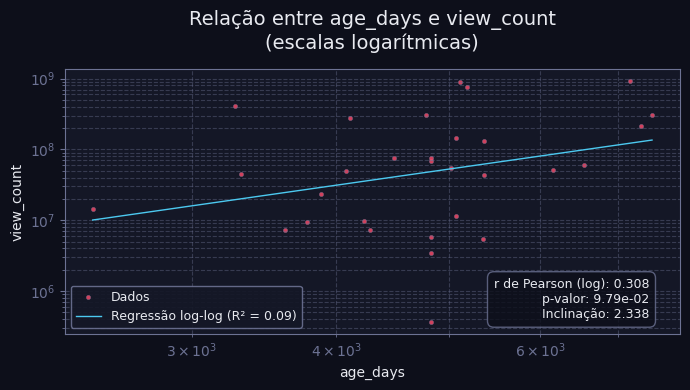

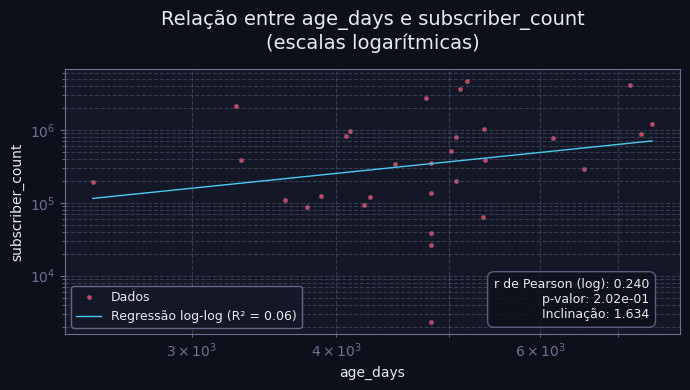

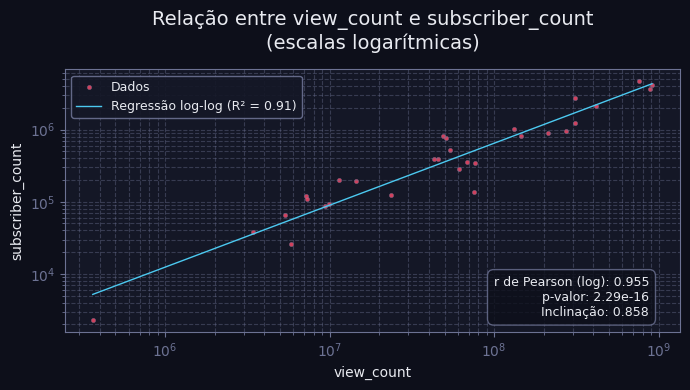

In [5]:

fig, ax, stats_result = static.plot_log_log_regression(
    processed_canais_df, 'age_days', 'view_count',figsize=(7, 4), return_stats=True
)
plt.show()
# print(f"R² = {stats_result['r_squared']:.3f}, p = {stats_result['p_value']:.2e}")


fig, ax, stats_result = static.plot_log_log_regression(
    processed_canais_df, 'age_days', 'subscriber_count',figsize=(7, 4), return_stats=True
)
plt.show()
# print(f"R² = {stats_result['r_squared']:.3f}, p = {stats_result['p_value']:.2e}")

fig, ax, stats_result = static.plot_log_log_regression(
    processed_canais_df, 'view_count', 'subscriber_count',figsize=(7, 4), return_stats=True
)
plt.show()
processed_canais_df.to_csv("processed_canais.csv", index=False)

In [6]:
videos_df = videos_df.drop(columns=["description"])


In [7]:
processed_videos_df = videos_df

In [8]:
display(videos_df.dtypes)
display(videos_df.isna().sum())

input_canal           str
channel_id            str
video_id              str
title                 str
published_at          str
channel_title         str
view_count            str
like_count            str
comment_count         str
duration              str
url                   str
raw_json              str
timestamp_execucao    str
dtype: object

input_canal             0
channel_id              0
video_id                0
title                   0
published_at            0
channel_title           0
view_count              8
like_count              7
comment_count         154
duration                1
url                     0
raw_json                0
timestamp_execucao      0
dtype: int64

In [9]:
# nltk.download('punkt_tab', quiet=True)

df = pd.read_csv('./processed_canais.csv')
df.dtypes

input_canal                   str
channel_id                    str
title                         str
custom_url                    str
description                   str
published_at                  str
country                       str
subscriber_count            int64
view_count                  int64
video_count                 int64
timestamp_execucao            str
description_word_count      int64
age_days                    int64
channel_age_days            int64
avg_views_per_video       float64
view_subscriber_ratio     float64
channel_tier                  str
dtype: object

In [10]:
"""
Pipeline NLP para análise de dados de vídeos do YouTube
Inclui: limpeza, preprocessamento, análise textual e visualizações
"""


import pandas as pd
import numpy as np
import re
import warnings
from typing import Tuple, List, Dict
import logging

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import SnowballStemmer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
import re

import emoji 
# Download de recursos NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
HAS_EMOJI = True


PROMOTIONAL_PATTERNS = [
    r"inscreva[- ]?se",
    r"ative o sininho",
    r"deixe o like",
    r"curta o vídeo",
    r"compartilhe",
    r"grupo de ofertas",
    r"canal de ofertas",
    r"cupom",
    r"desconto",
    r"patrocinado",
    r"apoie o canal",
    r"membro do canal",
    r"seja membro",
    r"instagram",
    r"facebook",
    r"twitter",
    r"x\.com",
    r"tiktok",
    r"telegram",
    r"whatsapp",
    r"linkedin",
    r"site oficial",
    r"baixe.*app",
]
import re
import emoji

def replace_emojis(text):
    text = emoji.demojize(text)

    # :fire: -> emoji_fire
    text = re.sub(
        r":([a-zA-Z0-9_&\-]+):",
        lambda m: f" emoji_{m.group(1)} ",
        text
    )

    return text


class YouTubeNLPPipeline:
    """Pipeline NLP para análise de dados de vídeos do YouTube"""
    
    def __init__(self, df: pd.DataFrame):
        """
        Inicializa a pipeline
        
        Args:
            df: DataFrame com dados de vídeos
        """
        self.df = df.copy()
        self.processed_df = None
        self.tfidf_matrix = None
        self.bow_matrix = None
        self.lda_model = None
        self.stemmer = SnowballStemmer('portuguese')
        self.stop_words = set(stopwords.words('portuguese'))
        
        logging.info("Pipeline inicializada")
    
    # ============ FASE 1: LIMPEZA E PREPARAÇÃO ============



    def clean_description(self,
        text: str,
        lowercase: bool = True,
        remove_promotional_lines: bool = True,
    ) -> str:
        """
        Limpeza de descrições para NLP.

        Remove:
        - URLs
        - Emojis
        - E-mails
        - Linhas promocionais
        - Redes sociais
        - Espaços e quebras excessivas

        Retorna texto limpo.
        """

        if not isinstance(text, str):
            return ""

        # URLs
        text = replace_emojis(text)
        text = re.sub(r"https?://\S+", " ", text)
        text = re.sub(r"www\.\S+", " ", text)

        # E-mails
        text = re.sub(
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            " ",
            text,
        )

        # Emojis
        if True:
            text = emoji.replace_emoji(text, replace="")
        else:
            text = re.sub(r"[\U00010000-\U0010FFFF]", "", text)

        # Remove linhas promocionais
        if remove_promotional_lines:
            cleaned_lines = []

            for line in text.splitlines():
                line = line.strip()

                if not line:
                    continue

                is_promotional = any(
                    re.search(pattern, line, flags=re.IGNORECASE)
                    for pattern in PROMOTIONAL_PATTERNS
                )

                if not is_promotional:
                    cleaned_lines.append(line)

            text = "\n".join(cleaned_lines)

        # Remove linhas duplicadas
        seen = set()
        unique_lines = []

        for line in text.splitlines():
            normalized = line.strip().lower()

            if normalized and normalized not in seen:
                seen.add(normalized)
                unique_lines.append(line.strip())

        text = "\n".join(unique_lines)

        # Remove caracteres especiais repetidos
        text = re.sub(r"[_*#=~`|>{}\[\]]+", " ", text)

        # Remove múltiplas quebras de linha
        text = re.sub(r"\n{2,}", "\n", text)

        # Remove múltiplos espaços
        text = re.sub(r"[ \t]+", " ", text)

        # Remove espaços ao redor das quebras
        text = re.sub(r" *\n *", "\n", text)

        if lowercase:
            text = text.lower()

        return text.strip()
    
    def limpar_dados(self) -> pd.DataFrame:
        """Limpa e prepara os dados"""
        logging.info("Iniciando limpeza de dados...")
        
        df = self.df.copy()
        
        # 1. Tratar valores ausentes
        df['like_count'] = df['like_count'].fillna(0)
        df['comment_count'] = df['comment_count'].fillna(0)
        df['duration'] = df['duration'].fillna('PT0M0S')
        
        # 2. Converter colunas numéricas
        for col in ['view_count', 'like_count', 'comment_count']:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        
        # 3. Converter datas
        df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce', utc=True)
        df['timestamp_execucao'] = pd.to_datetime(df['timestamp_execucao'], errors='coerce', utc=True)
        
        # 4. Remover duplicatas
        inicial = len(df)
        df = df.drop_duplicates(subset=['video_id'], keep='first')
        removidas = inicial - len(df)
        logging.info(f"Removidas {removidas} duplicatas")
        
        # 5. Remover linhas sem título
        df = df[df['title'].notna()]
        
        self.processed_df = df
        logging.info(f"Dados limpos: {len(df)} linhas")
        
        return df
    
    def converter_duration_segundos(self, duration_str: str) -> int:
        """Converte ISO 8601 duration para segundos"""
        if pd.isna(duration_str):
            return 0
        
        pattern = r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
        match = re.match(pattern, str(duration_str))
        
        if match:
            hours = int(match.group(1) or 0)
            minutes = int(match.group(2) or 0)
            seconds = int(match.group(3) or 0)
            return hours * 3600 + minutes * 60 + seconds
        return 0
    
    # ============ FASE 2: PREPROCESSAMENTO DE TEXTO ============
    
    def preprocessar_texto(self, texto: str) -> str:
        """
        Preprocessa um texto individual
        
        Steps:
        - Converter para minúsculas
        - Remover URLs
        - Remover caracteres especiais
        - Remover stopwords
        - Stemming
        """
        if not isinstance(texto, str):
            return ""
        
        # Minúsculas
        texto = texto.lower()
        
        # Remover URLs
        texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
        
        # Remover caracteres especiais (mantém apenas letras, números e espaços)
        texto = re.sub(r'[^a-záéíóúâêôãõç\s\d]', '', texto)
        
        # Remover espaços extras
        texto = ' '.join(texto.split())
        
        # Tokenização
        tokens = word_tokenize(texto)
        
        # Remover stopwords e aplicar stemming
        tokens = [self.stemmer.stem(token) for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return ' '.join(tokens)
    
    def criar_features_texto(self) -> pd.DataFrame:
        """Cria features baseadas em análise textual"""
        logging.info("Criando features de texto...")
        
        df = self.processed_df.copy()
        
        # Preprocessar título
        df['title_processed'] = df['title'].apply(lambda x: self.preprocessar_texto(texto=x))
        # Features baseadas no título original
        df['title_length'] = df['title'].apply(lambda x: len(str(x)))
        df['description_processed'] = df['description'].apply(lambda x: self.preprocessar_texto(texto=x))
        df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
        df['title_uppercase_ratio'] = df['title'].apply(
            lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
        )
        df['title_special_chars'] = df['title'].apply(
            lambda x: len(re.findall(r'[!?#*$%&()[\]{}<>]', str(x)))
        )
        df['title_has_number'] = df['title'].apply(lambda x: bool(re.search(r'\d', str(x))))
        
        # Análise de sentimento
        logging.info("Analisando sentimento...")
        df['title_sentiment'] = df['title'].apply(
            lambda x: TextBlob(str(x)).sentiment.polarity
        )
        df['title_subjectivity'] = df['title'].apply(
            lambda x: TextBlob(str(x)).sentiment.subjectivity
        )
        
        self.processed_df = df
        return df
    
    # ============ FASE 3: ANÁLISE TEXTUAL AVANÇADA ============
    
    def calcular_tfidf(self, max_features: int = 100) -> np.ndarray:
        """Calcula matriz TF-IDF dos títulos"""
        logging.info("Calculando TF-IDF...")
        
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        
        self.tfidf_matrix = vectorizer.fit_transform(
            self.processed_df['title_processed']
        )
        self.tfidf_vectorizer = vectorizer
        
        return self.tfidf_matrix
    
    def extrair_palavras_chave(self, top_n: int = 10) -> Dict[str, float]:
        """Extrai palavras-chave mais relevantes"""
        if self.tfidf_matrix is None:
            self.calcular_tfidf()
        
        feature_names = self.tfidf_vectorizer.get_feature_names_out()
        tfidf_scores = self.tfidf_matrix.sum(axis=0).A1
        
        top_indices = np.argsort(tfidf_scores)[-top_n:][::-1]
        
        return {feature_names[i]: tfidf_scores[i] for i in top_indices}
    
    def analise_topicos_lda(self, n_topics: int = 5, max_iter: int = 10):
        """Aplica Latent Dirichlet Allocation para descobrir tópicos"""
        logging.info(f"Descobrindo {n_topics} tópicos com LDA...")
        
        # Criar bag of words
        vectorizer = CountVectorizer(
            max_features=100,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        
        bow_matrix = vectorizer.fit_transform(
            self.processed_df['title_processed']
        )
        self.bow_matrix = bow_matrix
        
        # LDA
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            max_iter=max_iter,
            random_state=42
        )
        lda.fit(bow_matrix)
        self.lda_model = lda
        
        # Extrair tópicos
        feature_names = vectorizer.get_feature_names_out()
        topics = {}
        
        for topic_id, topic in enumerate(lda.components_):
            top_words_idx = topic.argsort()[-5:][::-1]
            top_words = [feature_names[i] for i in top_words_idx]
            topics[f"topic_{topic_id}"] = top_words
        
        return topics
    
    # ============ FASE 4: ANÁLISE DE MÉTRICAS ============
    
    def calcular_metricas_engajamento(self) -> pd.DataFrame:
        """Calcula métricas de engajamento"""
        logging.info("Calculando métricas de engajamento...")
        
        df = self.processed_df.copy()
        
        # Converter duration
        df['duration_segundos'] = df['duration'].apply(self.converter_duration_segundos)
        
        # Taxa de engajamento
        df['engagement_rate'] = (
            (df['like_count'] + df['comment_count']) / 
            (df['view_count'] + 1)  # +1 para evitar divisão por zero
        ) * 100
        
        # Comment rate
        df['comment_rate'] = (df['comment_count'] / (df['view_count'] + 1)) * 100
        
        # Like rate
        df['like_rate'] = (df['like_count'] / (df['view_count'] + 1)) * 100
        
        # Like/Comment ratio
        df['like_comment_ratio'] = (df['like_count'] / (df['comment_count'] + 1))
        
        # Dias desde publicação
        df['dias_publicacao'] = (
            (df['timestamp_execucao'] - df['published_at']).dt.days
        ).clip(lower=0)
        
        # Visualizações por dia
        df['views_per_day'] = (
            df['view_count'] / (df['dias_publicacao'] + 1)
        )
        
        self.processed_df = df
        return df
    
    # ============ FASE 5: VALIDAÇÃO ============
    
    def validar_pipeline(self) -> Dict[str, any]:
        """Valida a integridade da pipeline"""
        logging.info("Validando pipeline...")
        
        validation = {
            'total_registros': len(self.processed_df),
            'colunas_esperadas': list(self.processed_df.columns),
            'valores_ausentes': self.processed_df.isnull().sum().to_dict(),
            'tipos_dados': self.processed_df.dtypes.to_dict(),
            'duplicatas': self.processed_df.duplicated(subset=['video_id']).sum(),
        }
        
        return validation
    
    # ============ VISUALIZAÇÕES ============
    
    def gerar_relatorio_visual(self, save_path: str = None):
        """Gera relatório visual da análise"""
        logging.info("Gerando relatório visual...")
        
        df = self.processed_df
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Análise NLP - Relatório Executivo', fontsize=16, fontweight='bold')
        
        # 1. Distribuição de comprimento de título
        axes[0, 0].hist(df['title_length'], bins=30, color='skyblue', edgecolor='black')
        axes[0, 0].set_title('Distribuição de Comprimento do Título')
        axes[0, 0].set_xlabel('Caracteres')
        axes[0, 0].set_ylabel('Frequência')
        
        # 2. Sentimento dos títulos
        axes[0, 1].scatter(df['title_sentiment'], df['view_count'], 
                          alpha=0.6, color='coral', s=50)
        axes[0, 1].set_title('Sentimento vs Visualizações')
        axes[0, 1].set_xlabel('Polarity (Sentimento)')
        axes[0, 1].set_ylabel('Visualizações')
        axes[0, 1].set_yscale('log')
        
        # 3. Taxa de engajamento
        engagement_clean = df['engagement_rate'].replace([np.inf, -np.inf], 0).clip(0, 100)
        axes[0, 2].hist(engagement_clean, bins=30, color='lightgreen', edgecolor='black')
        axes[0, 2].set_title('Distribuição de Taxa de Engajamento')
        axes[0, 2].set_xlabel('Engajamento (%)')
        axes[0, 2].set_ylabel('Frequência')
        
        # 4. Palavras-chave mais frequentes
        palavras = self.extrair_palavras_chave(top_n=10)
        axes[1, 0].barh(list(palavras.keys()), list(palavras.values()), color='mediumslateblue')
        axes[1, 0].set_title('Top 10 Palavras-chave (TF-IDF)')
        axes[1, 0].set_xlabel('Score TF-IDF')
        
        # 5. Relação: comprimento título vs views
        axes[1, 1].scatter(df['title_word_count'], df['view_count'], 
                          alpha=0.6, color='seagreen', s=50)
        axes[1, 1].set_title('Palavras no Título vs Visualizações')
        axes[1, 1].set_xlabel('Número de Palavras')
        axes[1, 1].set_ylabel('Visualizações')
        axes[1, 1].set_yscale('log')
        
        # 6. Cronologia de publicações
        timeline = df.groupby(df['published_at'].dt.date)['video_id'].count()
        axes[1, 2].plot(timeline.index, timeline.values, marker='o', color='purple', linewidth=2)
        axes[1, 2].set_title('Vídeos Publicados por Dia')
        axes[1, 2].set_xlabel('Data')
        axes[1, 2].set_ylabel('Quantidade')
        axes[1, 2].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logging.info(f"Relatório salvo em: {save_path}")
        
        return fig
    
    # ============ EXECUÇÃO COMPLETA ============
    
    def executar_pipeline_completa(self) -> pd.DataFrame:
        """Executa toda a pipeline de uma vez"""
        logging.info("=" * 50)
        logging.info("INICIANDO PIPELINE COMPLETA")
        logging.info("=" * 50)
        
        # Fase 1
        # self.clean_description()

        self.limpar_dados()
        
        # Fase 2
        self.criar_features_texto()
        
        # Fase 3
        self.calcular_tfidf()
        palavras_chave = self.extrair_palavras_chave()
        logging.info(f"Palavras-chave extraídas: {list(palavras_chave.keys())[:5]}")
        
        topicos = self.analise_topicos_lda(n_topics=5)
        logging.info(f"Tópicos descobertos: {list(topicos.keys())}")
        
        # Fase 4
        self.calcular_metricas_engajamento()
        
        # Fase 5
        validacao = self.validar_pipeline()
        logging.info(f"Validação: {validacao['total_registros']} registros processados")
        
        logging.info("=" * 50)
        logging.info("PIPELINE CONCLUÍDA COM SUCESSO")
        logging.info("=" * 50)
        
        return self.processed_df


# ============ EXEMPLO DE USO ============

if __name__ == "__main__":
    # Carregar dados
    df = pd.read_csv('../data/2026-06-26_12-06/videos.csv')  # Substitua pelo seu arquivo
    
    # Criar e executar pipeline
    pipeline = YouTubeNLPPipeline(df)
    
    # Executar completo
    resultado = pipeline.executar_pipeline_completa()
    
    # Gerar visualizações
    pipeline.gerar_relatorio_visual('relatorio_nlp.png')
    
    # Salvar resultado
    resultado.to_csv('dados_processados.csv', index=False)
    
    # Exibir amostra
    print("\n" + "=" * 50)
    print("AMOSTRA DOS DADOS PROCESSADOS")
    print("=" * 50)
    print(resultado[['title', 'title_length', 'title_sentiment', 
                     'engagement_rate', 'view_count']].head())
    
    print("\n" + "=" * 50)
    print("ESTATÍSTICAS")
    print("=" * 50)
    print(resultado[['title_sentiment', 'engagement_rate', 'like_rate', 
                     'comment_rate']].describe())

INFO:root:Pipeline inicializada
INFO:root:==================================================
INFO:root:INICIANDO PIPELINE COMPLETA
INFO:root:==================================================
INFO:root:Iniciando limpeza de dados...
INFO:root:Removidas 0 duplicatas
INFO:root:Dados limpos: 1451 linhas
INFO:root:Criando features de texto...
INFO:root:Analisando sentimento...
INFO:root:Calculando TF-IDF...
INFO:root:Palavras-chave extraídas: ['nov', 'liv', 'melhor', 'dev', 'shorts']
INFO:root:Descobrindo 5 tópicos com LDA...
INFO:root:Tópicos descobertos: ['topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4']
INFO:root:Calculando métricas de engajamento...
INFO:root:Validando pipeline...
INFO:root:Validação: 1451 registros processados
INFO:root:==================================================
INFO:root:PIPELINE CONCLUÍDA COM SUCESSO
INFO:root:==================================================
INFO:root:Gerando relatório visual...
INFO:root:Relatório salvo em: relatorio_nlp.png



AMOSTRA DOS DADOS PROCESSADOS
                                               title  title_length  \
0  CT Responde: Tire suas dúvidas de tecnologia a...            53   
1  Anel que afere a pressão arterial: RingCon Gen...            69   
2    IBM ANUNCIA CHIP COM TECNOLOGIA REVOLUCIONÁRIA!            47   
3   RELÓGIO DOS ÁRBITROS NA COPA CUSTA 20 MIL REAIS!            48   
4  IPHONE DOURADO DO ROBERTO CARLOS PODE CUSTAR M...            62   

   title_sentiment  engagement_rate  view_count  
0              0.0        10.567010        1939  
1              0.0        15.782720        2337  
2              0.0        13.609300        3526  
3              0.0         8.580232        4218  
4              0.0         7.122323       27827  

ESTATÍSTICAS
       title_sentiment  engagement_rate    like_rate  comment_rate
count      1451.000000      1451.000000  1451.000000   1451.000000
mean          0.011544         9.722823     9.184144      0.538679
std           0.109672        29.

In [11]:
resultado.to_csv('filename.csv', index=False)
# nltk.download('punkt_tab', quiet=True)
print(resultado.dtypes)
df = pd.read_csv('./processed_canais.csv')
df.dtypes


input_canal                              str
channel_id                               str
video_id                                 str
title                                    str
description                              str
published_at             datetime64[us, UTC]
channel_title                            str
view_count                             int64
like_count                             int64
comment_count                          int64
duration                                 str
url                                      str
raw_json                                 str
timestamp_execucao       datetime64[us, UTC]
title_processed                          str
title_length                           int64
description_processed                    str
title_word_count                       int64
title_uppercase_ratio                float64
title_special_chars                    int64
title_has_number                        bool
title_sentiment                      float64
title_subj

input_canal                   str
channel_id                    str
title                         str
custom_url                    str
description                   str
published_at                  str
country                       str
subscriber_count            int64
view_count                  int64
video_count                 int64
timestamp_execucao            str
description_word_count      int64
age_days                    int64
channel_age_days            int64
avg_views_per_video       float64
view_subscriber_ratio     float64
channel_tier                  str
dtype: object

In [12]:
processed_canais_df = pd.read_csv('./processed_canais.csv')

df_final = resultado.merge(
    processed_canais_df,
    on="channel_id",
    how="left",
    suffixes=("", "_canal")
)

In [13]:
df_final.to_csv("merged.csv", index=False)

In [14]:
import pandas as pd
df_final = pd.read_csv("merged.csv")
df_final.dtypes

input_canal                     str
channel_id                      str
video_id                        str
title                           str
description                     str
published_at                    str
channel_title                   str
view_count                    int64
like_count                    int64
comment_count                 int64
duration                        str
url                             str
raw_json                        str
timestamp_execucao              str
title_processed                 str
title_length                  int64
description_processed           str
title_word_count              int64
title_uppercase_ratio       float64
title_special_chars           int64
title_has_number               bool
title_sentiment             float64
title_subjectivity          float64
duration_segundos             int64
engagement_rate             float64
comment_rate                float64
like_rate                   float64
like_comment_ratio          

In [15]:
videos_por_canal = (
    df_final.groupby("channel_id")
    .size()
    .reset_index(name="n_videos")
    .sort_values("n_videos", ascending=False)
)

print(videos_por_canal.tail(20))
print(videos_por_canal["n_videos"].describe())
df_final = df_final[df_final['channel_id']!='UCXqPMnmnSfJuIqHNtaIaWvQ']
df_final.to_csv("merged.csv", index=False)


                  channel_id  n_videos
10  UCSfwM5u0Kce6Cce8_S72olg        50
11  UCU5JicSrEM5A63jkJ2QvGYw        50
13  UCY5nGkuALqkKKOVhivryH3A        50
14  UCYScNUfCLI_LBmUzfHIZ0lg        50
22  UCo4-WGKOvw3QmzW8MRuuFtQ        50
15  UC_bXJnsgwOqEPA_-6N6faKw        50
16  UCaftHbsPdXaHEwLQdIXGxbQ        50
17  UCbK5Us4E-HsXw6fQ1PYUuog        50
18  UCdmGjywrxeOPfC7vDllmSgQ        50
19  UCg1nJKjie4vb8FILBbv3F6A        50
20  UCgnACLvM9O5lfm9ZBh_d3cg        50
21  UCjF0OccBT05WxsJb2zNkL4g        50
26  UCrWvhVmt0Qac3HgsjQK62FQ        50
23  UCpKvMmsF6QrkVr_zWaLGK-A        50
24  UCplT2lzN6MHlVHHLt6so39A        50
25  UCqpNnEzmmlzBfdy3X0eMOMg        50
28  UCyJfHnEgLnvrjQcPsR3UVeQ        50
27  UCyHOBY6IDZF9zOKJPou2Rgg        50
29  UCzOGJclZQvPVgYZIwERsf5g        50
12  UCXqPMnmnSfJuIqHNtaIaWvQ         1
count    30.000000
mean     48.366667
std       8.946135
min       1.000000
25%      50.000000
50%      50.000000
75%      50.000000
max      50.000000
Name: n_videos, dtype: float6

In [16]:
import numpy as np
import pandas as pd


def postprocess_dataset(
    df: pd.DataFrame,
    drop_unused_columns: bool = True
) -> pd.DataFrame:
    """
    Pós-processamento para datasets de vídeos do YouTube.

    - Limpeza de NaN e infinitos
    - Features temporais
    - Features textuais
    - Features de engajamento
    - Transformações logarítmicas
    - Classificação de duração
    - Remoção de colunas redundantes
    """

    df = df.copy()

    # =====================================================
    # Limpeza
    # =====================================================

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    numeric_cols = df.select_dtypes(
        include=[np.number]
    ).columns

    df[numeric_cols] = df[numeric_cols].fillna(0)

    text_cols = [
        "title_processed",
        "description_processed",
        "title",
        "description",
    ]

    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
                .str.strip()
            )

    # =====================================================
    # Datas
    # =====================================================

    if "published_at" in df.columns:

        df["published_at"] = pd.to_datetime(
            df["published_at"],
            errors="coerce",
            utc=True
        )

        if df["published_at"].notna().any():

            df["published_hour"] = df["published_at"].dt.hour
            df["published_weekday"] = df["published_at"].dt.dayofweek
            df["published_month"] = df["published_at"].dt.month
            df["published_year"] = df["published_at"].dt.year
            df["published_weekend"] = (
                df["published_weekday"] >= 5
            )

    # =====================================================
    # Texto
    # =====================================================

    if "description_processed" in df.columns:

        df["description_length"] = (
            df["description_processed"]
            .str.len()
        )

        df["description_word_count"] = (
            df["description_processed"]
            .str.split()
            .str.len()
        )

    if (
        "description_word_count" in df.columns
        and "title_word_count" in df.columns
    ):
        df["description_title_ratio"] = (
            df["description_word_count"]
            / (df["title_word_count"] + 1)
        )

    if "title" in df.columns:

        df["title_question"] = (
            df["title"]
            .str.contains(r"\?", regex=True)
        )

        df["title_exclamation"] = (
            df["title"]
            .str.contains(r"!", regex=True)
        )

    # =====================================================
    # Popularidade
    # =====================================================

    if {
        "view_count",
        "like_count"
    }.issubset(df.columns):

        df["likes_per_view"] = (
            df["like_count"]
            / (df["view_count"] + 1)
        )

    if {
        "view_count",
        "comment_count"
    }.issubset(df.columns):

        df["comments_per_view"] = (
            df["comment_count"]
            / (df["view_count"] + 1)
        )

    # =====================================================
    # Logs
    # =====================================================

    log_cols = [
        "view_count",
        "like_count",
        "comment_count",
        "views_per_day",
    ]

    for col in log_cols:

        if col in df.columns:

            df[f"{col}_log"] = np.log1p(
                df[col].clip(lower=0)
            )

    # =====================================================
    # Duração
    # =====================================================

    if "duration_segundos" in df.columns:

        df["is_short"] = (
            df["duration_segundos"] <= 60
        )

        df["duration_class"] = pd.cut(
            df["duration_segundos"],
            bins=[
                -1,
                60,
                300,
                1200,
                3600,
                np.inf
            ],
            labels=[
                "short",
                "medium",
                "long",
                "very_long",
                "extreme"
            ]
        )

    # =====================================================
    # Faixas de views
    # =====================================================

    if (
        "view_count" in df.columns
        and len(df) >= 5
    ):
        try:
            df["view_tier"] = pd.qcut(
                df["view_count"].rank(
                    method="first"
                ),
                q=5,
                labels=[
                    "very_low",
                    "low",
                    "medium",
                    "high",
                    "viral"
                ]
            )
        except Exception:
            pass

    # =====================================================
    # Flags
    # =====================================================

    if "description_length" in df.columns:
        df["has_description"] = (
            df["description_length"] > 0
        )

    if "comment_count" in df.columns:
        df["has_comments"] = (
            df["comment_count"] > 0
        )

    if "like_count" in df.columns:
        df["has_likes"] = (
            df["like_count"] > 0
        )

    # =====================================================
    # Duplicados
    # =====================================================

    if "video_id" in df.columns:
        df = df.drop_duplicates(
            subset=["video_id"]
        )

    # =====================================================
    # Remoção de colunas inúteis
    # =====================================================

    if drop_unused_columns:

        columns_to_drop = [
            "raw_json",
            "url",
            "input_canal",
            "channel_id",
            "channel_title",
            "duration",
            "timestamp_execucao",
            "published_at",
        ]

        existing_cols = [
            c
            for c in columns_to_drop
            if c in df.columns
        ]

        df.drop(
            columns=existing_cols,
            inplace=True,
            errors="ignore"
        )

    # =====================================================
    # Categorias → string
    # =====================================================

    categorical_cols = [
        "duration_class",
        "view_tier",
    ]

    for col in categorical_cols:

        if col in df.columns:
            df[col] = df[col].astype(str)

    return df

In [17]:
df_final_ = postprocess_dataset(df_final)
df_final_ = df_final_.drop(columns=["title", "description"])
df_final_.to_csv("merged_postprocessed.csv", index=False)

In [18]:
df_final_.dtypes

video_id                        str
view_count                    int64
like_count                    int64
comment_count                 int64
title_processed                 str
title_length                  int64
description_processed           str
title_word_count              int64
title_uppercase_ratio       float64
title_special_chars           int64
title_has_number               bool
title_sentiment             float64
title_subjectivity          float64
duration_segundos             int64
engagement_rate             float64
comment_rate                float64
like_rate                   float64
like_comment_ratio          float64
dias_publicacao               int64
views_per_day               float64
input_canal_canal               str
title_canal                     str
custom_url                      str
description_canal               str
published_at_canal              str
country                         str
subscriber_count            float64
view_count_canal            